In [18]:
import polars as pl


df = pl.read_json("../data/test_server_eval/Qwen_Qwen2.5-VL-3B-Instruct/all_results.json")
df = df.with_columns(
    pl.mean_horizontal("language/Bleu_1", "language/Bleu_2", "language/Bleu_3", "language/Bleu_4", "language/ROUGE_L", "language/CIDEr").alias("language"),
    (pl.col("chatgpt") / 100).alias("chatgpt"),
    (pl.col("match") / 100).alias("match")
)

print(df["approach"])
df.write_csv("all-results-3B.csv")

shape: (9,)
Series: 'approach' [str]
[
	"baseline"
	"FrontCam_SystemPrompt"
	"ImageGrid_SystemPrompt"
	"AddKois_FrontCam_SystemPrompt"
	"SystemPrompt_ImageGrid_AddKois"
	"AddKois_SystemPrompt_AddBev"
	"AddKois_SystemPrompt_AddBev_Fr…
	"FrontCam_AddKois_SystemPrompt_…
	"SystemPrompt_AddKois"
]


In [19]:
df = df.filter(
    pl.col("approach").is_in([
        "baseline",
        "FrontCam_SystemPrompt",
        "AddKois_FrontCam_SystemPrompt",
        "AddKois_SystemPrompt_AddBev_FrontCam",
        "SystemPrompt_ImageGrid_AddKois",
    ])
)
print(df["language"])
approach_chart = pl.Series(
    "approach_chart",
    [
        "Baseline",
        "+ System Prompt",
        "+ Object Detection",
        "BEV + Front Camera",
        "Image Grid"
    ]
)
df = df.insert_column(1, approach_chart)

shape: (5,)
Series: 'language' [f64]
[
	0.105105
	0.347277
	0.346958
	0.414583
	0.33971
]


In [20]:
print(df.select("approach", "language"))

shape: (5, 2)
┌─────────────────────────────────┬──────────┐
│ approach                        ┆ language │
│ ---                             ┆ ---      │
│ str                             ┆ f64      │
╞═════════════════════════════════╪══════════╡
│ baseline                        ┆ 0.105105 │
│ FrontCam_SystemPrompt           ┆ 0.347277 │
│ AddKois_FrontCam_SystemPrompt   ┆ 0.346958 │
│ SystemPrompt_ImageGrid_AddKois  ┆ 0.414583 │
│ AddKois_SystemPrompt_AddBev_Fr… ┆ 0.33971  │
└─────────────────────────────────┴──────────┘


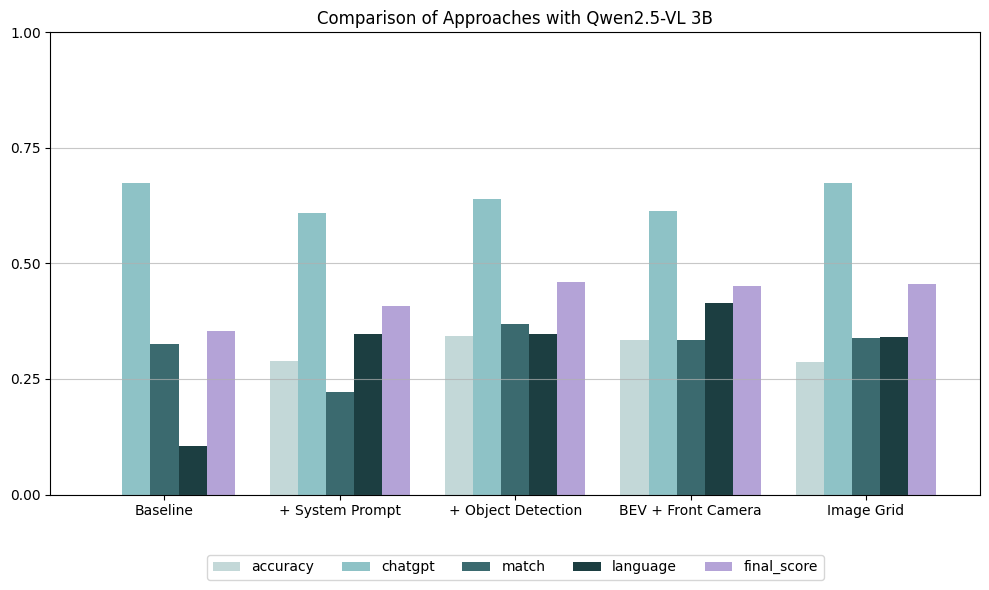

In [ ]:
import matplotlib.pyplot as plt



pd_df = df.select("approach_chart", "accuracy", "chatgpt", "match", "language", "final_score").to_pandas()
pd_df = pd_df.set_index('approach_chart')

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

pd_df.plot(kind='bar', ax=ax, width=0.8, color=['#c3d8d8', '#8ec2c6', '#3b6a6f', '#1c3e41', '#B4A3D7'])

# Customize the plot to match the image
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='-', alpha=0.7)

# Add a star to the 'Language' label in the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)
ax.set_title("Comparison of Approaches with Qwen2.5-VL 3B")

plt.tight_layout()
plt.savefig("approaches_qwen25-3b.png")
plt.show()
